In [34]:
from pathlib import Path

from lib.fs.get_script_name import get_name
from lib.fs.project_config import REPO_ROOT
from plotting import plot_config

script_name = get_name()
out_dir = REPO_ROOT / "figures" / script_name
    
from lib.fs.get_script_name import get_name
script_name = get_name()

import matplotlib.pyplot as plt
import numpy as np
import h5py

In [35]:
SUBJECT_ID = "sub-NDARINVAG388HJL"
FILE_SUFFIX = "_task-restAP_run-01_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.h5"

# FILE_DIR = Path("/cluster/work/ianpe/bids_processed_consolidated_data") # IDUN
FILE_DIR = Path("/Users/ipeglin/Documents/masters_thesis/bids_processed_consolidated_data") # LOCAL
FILE_PATH = FILE_DIR / SUBJECT_ID / f"{SUBJECT_ID}{FILE_SUFFIX}"

ROI_IDX = 2 # lAMY-rh

In [36]:
out_dir = REPO_ROOT / "figures" / script_name
out_dir.mkdir(exist_ok=True)

In [37]:
# plotting first ROI
ROI_IDX = 0

In [38]:
with h5py.File(FILE_PATH, 'r') as f:
  std_ts = np.asarray(f['01fmri_parcellation/full_run_std'])
  

/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_281/1308024039.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.98])


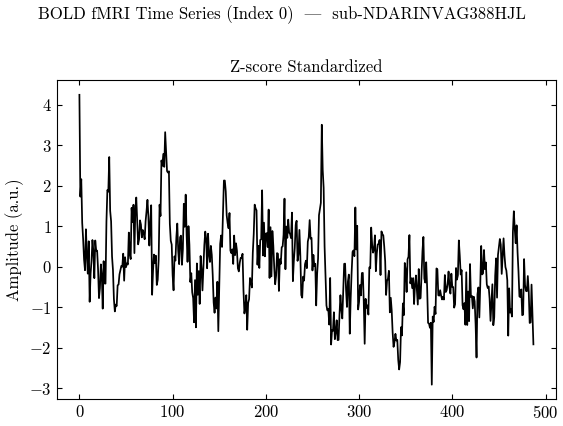

In [39]:
fig = plt.figure()
plt.plot(std_ts[ROI_IDX], c="k")
plt.ylabel("Amplitude (a.u.)")
plt.title("Z-score Standardized")

plt.suptitle(f"BOLD fMRI Time Series (Index {ROI_IDX})  |  {SUBJECT_ID}")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(out_dir / f"timeseries_roi{ROI_IDX}_raw_vs_std")